# Project 2 — Iris Dataset Clustering (Deep Dive)

**Business/scientific framing:** Imagine you're a botanist who collected 150 flower measurements
but (hypothetically) **lost the species labels**. Can hierarchical clustering rediscover the
natural groupings purely from petal/sepal measurements? This is a classic real-world use case
of clustering: **discovering unknown categories in data.**

This notebook goes deeper than the theory notebook: we'll compare all 4 linkage methods on the
real Iris data, evaluate against ground truth, and discuss the result like a real data scientist would.


## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, confusion_matrix, adjusted_rand_score

from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)

iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Quick EDA

In [2]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


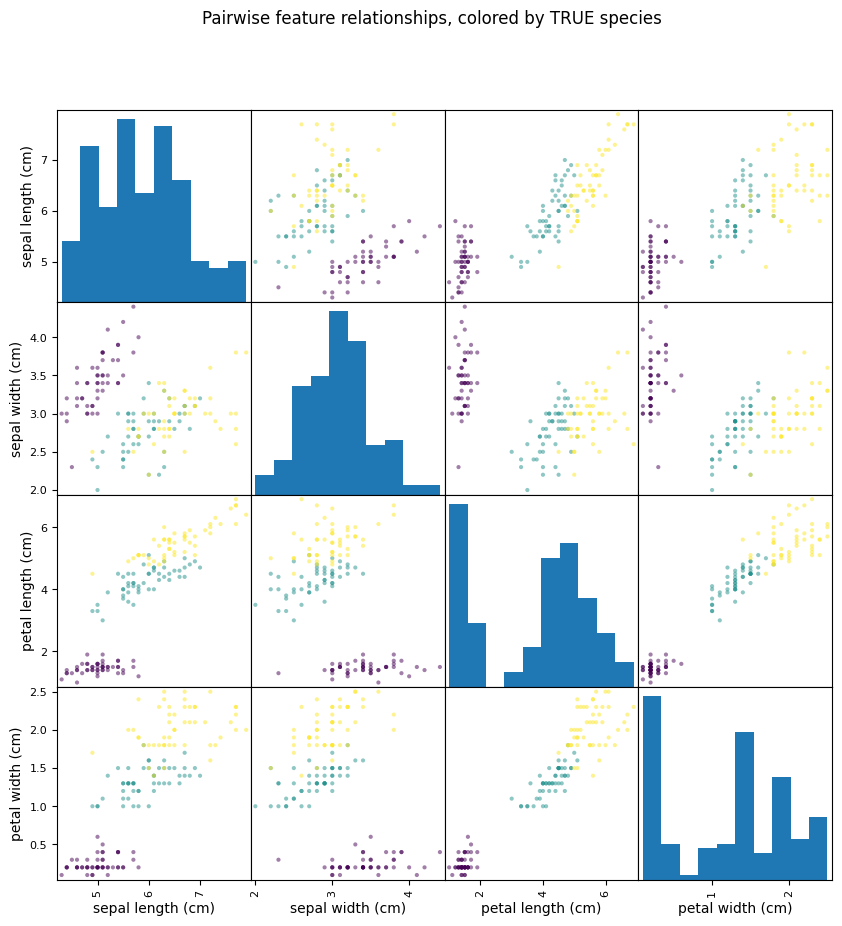

In [3]:
pd.plotting.scatter_matrix(df.iloc[:, :4], c=iris.target, figsize=(10, 10), cmap='viridis', diagonal='hist')
plt.suptitle('Pairwise feature relationships, colored by TRUE species')
plt.show()


Notice: `setosa` (one color) is already visually well-separated from the other two, which heavily overlap. Keep this in mind — it explains a lot of what we'll see later.

## 3. Preprocessing — Scale + PCA

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.iloc[:, :4])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance explained by 2 PCA components:", pca.explained_variance_ratio_.sum().round(3))


Variance explained by 2 PCA components: 0.958


## 4. Compare All 4 Linkage Methods

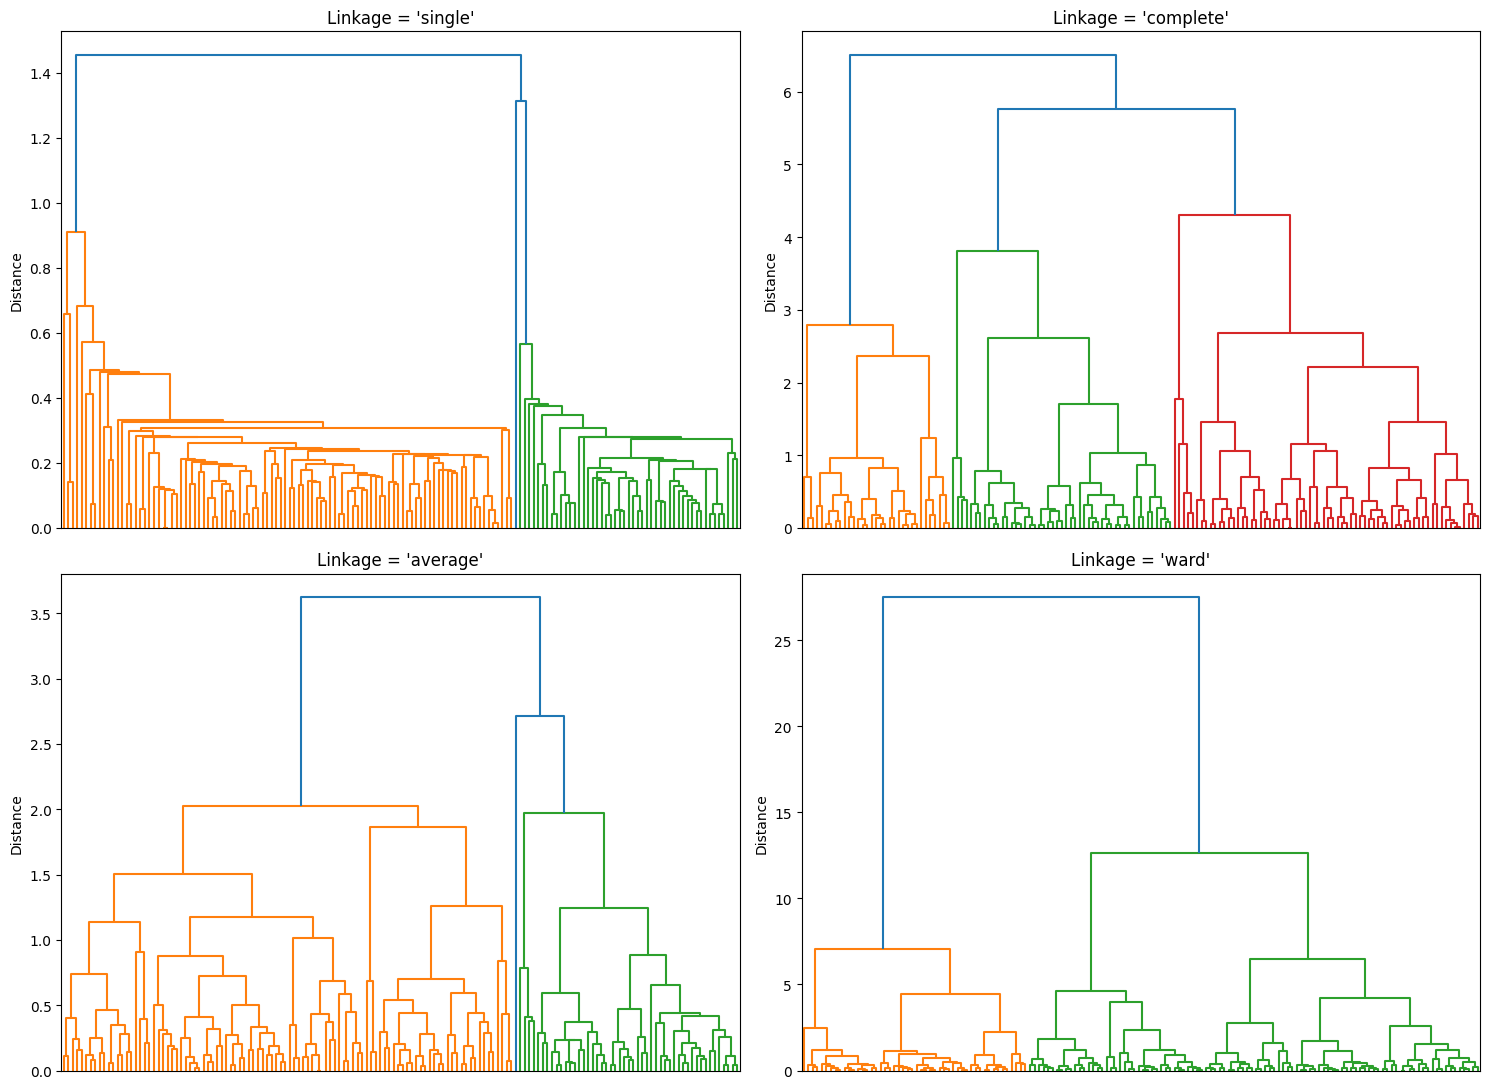

In [5]:
methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.ravel()
for ax, m in zip(axes, methods):
    Z = linkage(X_pca, method=m)
    dendrogram(Z, ax=ax, no_labels=True)
    ax.set_title(f"Linkage = '{m}'")
    ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()


**What to notice:**
- `single` linkage tends to "chain" points together and looks messy/ambiguous for choosing k.
- `complete` and `average` are more balanced.
- `ward` (like in the theory notebook) usually gives the cleanest split for this dataset.

## 5. Cluster with Each Linkage Method & Compare to Ground Truth

In [6]:
results = []
for m in methods:
    model = AgglomerativeClustering(n_clusters=3, metric='euclidean' if m != 'ward' else 'euclidean', linkage=m)
    pred = model.fit_predict(X_pca)
    sil = silhouette_score(X_pca, pred)
    ari = adjusted_rand_score(iris.target, pred)  # how well predicted clusters match TRUE species (0=random, 1=perfect)
    results.append({'linkage': m, 'silhouette_score': round(sil, 3), 'adjusted_rand_index': round(ari, 3)})

results_df = pd.DataFrame(results)
results_df


,linkage,silhouette_score,adjusted_rand_index
0,single,0.538,0.558
1,complete,0.505,0.625
2,average,0.538,0.558
3,ward,0.511,0.586


**Adjusted Rand Index (ARI)** measures how well our clusters match the *true* species labels
(1.0 = perfect match, 0.0 = random). This is only possible to compute here because we *happen to
have* the ground truth for this dataset — in most real projects you won't have this luxury, which
is exactly why the dendrogram + silhouette score approach matters so much.

## 6. Best Model — Detailed Look (Ward Linkage)

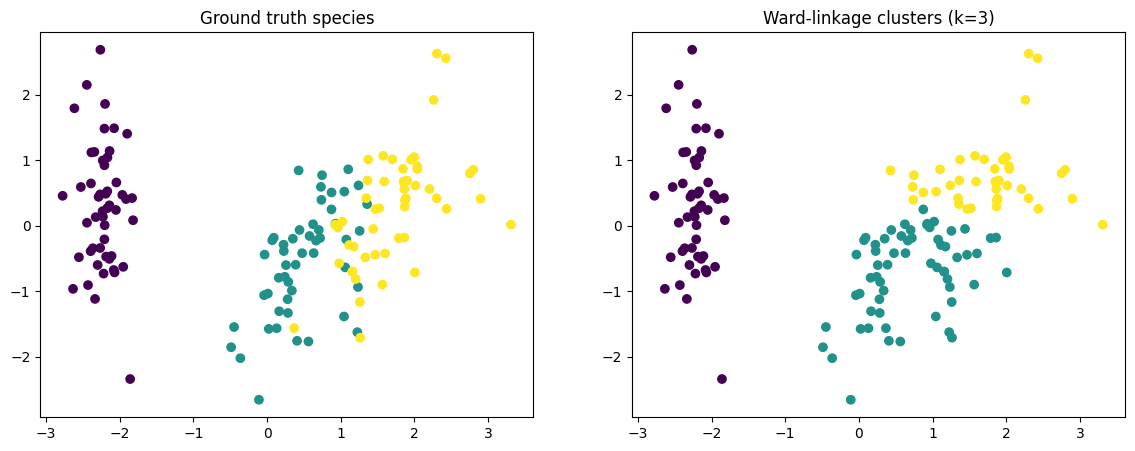

In [7]:
best_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['cluster'] = best_model.fit_predict(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=iris.target, cmap='viridis')
axes[0].set_title('Ground truth species')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis')
axes[1].set_title('Ward-linkage clusters (k=3)')
plt.show()


In [ ]:
cm = confusion_matrix(iris.target, df['cluster'])
cm_df = pd.DataFrame(cm, index=iris.target_names, columns=[f'Cluster {i}' for i in range(3)])
cm_df


**Interpretation:** `setosa` is almost always perfectly isolated into its own cluster.
The confusion between `versicolor` and `virginica` reflects a genuine biological overlap in their
petal/sepal measurements — not a flaw in the algorithm. This is a great real interview talking
point: *clustering results should always be validated against domain knowledge, not blindly trusted.*

## 7. What if We Only Ask for k=2? (Revisiting the Notes' Point)

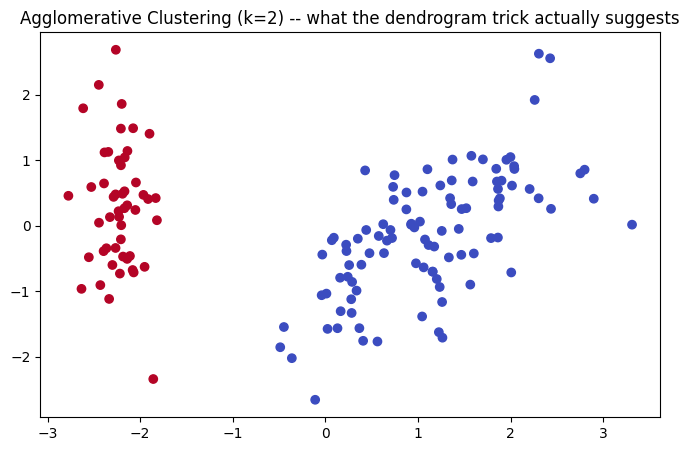

Silhouette score (k=2): 0.615
Silhouette score (k=3): 0.511


In [8]:
model_k2 = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
labels_k2 = model_k2.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_k2, cmap='coolwarm')
plt.title('Agglomerative Clustering (k=2) -- what the dendrogram trick actually suggests')
plt.show()

print("Silhouette score (k=2):", round(silhouette_score(X_pca, labels_k2), 3))
print("Silhouette score (k=3):", round(silhouette_score(X_pca, df['cluster']), 3))


Notice the silhouette score is often actually **higher** for k=2! This matches what the theory
notes said: the dendrogram's "longest vertical line" trick honestly suggests 2 clusters because
versicolor+virginica are naturally close together — a perfect example of why domain knowledge
(here: "we know there are 3 species biologically") sometimes has to override a purely statistical
suggestion, or at least be discussed together with it.

## 8. Try It Yourself

- Try clustering on the ORIGINAL 4 features (skip PCA) and see if results change.
- Try `AgglomerativeClustering(distance_threshold=..., n_clusters=None)` to let sklearn pick k automatically from a distance threshold.
- Explore `sklearn.metrics.classification_report`-style analysis by treating clusters as if they were predictions.
